In [14]:
import matplotlib.pyplot as plt
from typing import List
import glob
import os
import numpy as np
import pandas as pd
import seaborn as sns

In [15]:
NUMBER_OF_FLOWS = 50

STEPS = 5

INTERVAL_LENGTH = int(NUMBER_OF_FLOWS / STEPS)

SESSIONS = np.arange(0, NUMBER_OF_FLOWS, step=INTERVAL_LENGTH)

In [16]:
def acceptance_rate(ar_array) -> List:
    slices = np.array_split(ar_array, INTERVAL_LENGTH)
    ar_result = []
    for slice in slices:
        values, counts = np.unique(slice, return_counts=True)
        if len(counts) == 1:
            if values[0] == 0:
                acc_rate = 0
            elif values[0] == 1:
                acc_rate = 1
        else:
            count_succ = counts[1]
            count_fail = counts[0]
            acc_rate = count_succ / (count_succ + count_fail)
        ar_result.append(acc_rate)

    return ar_result

In [17]:
def resource_utilization(ar_array) -> List:
    slices = np.array_split(ar_array, INTERVAL_LENGTH)
    resource_result = []
    for slice in slices:
        if len(slice) == 0:
            continue
        average_consumption = np.mean(slice)
        resource_result.append(average_consumption)

    return resource_result

In [97]:
def plot_resource_utilization(resource_series: pd.Series, title, n_alg, y_lim):

    index_resource = pd.MultiIndex.from_tuples(
        dict(resource_series).keys(), names=["sfc", "algorithm", "speed", "exec"]
    )

    resource_df = pd.DataFrame.from_dict(dict(resource_series), orient="index")

    resource_df = resource_df.set_index(index_resource)

    grouped_resource = resource_df.groupby(level=("sfc", "algorithm", "speed"))

    mean_df = grouped_resource.mean()
    std_df = grouped_resource.std()

    mean_df = mean_df.stack().to_frame("mean")
    mean_df["std"] = std_df.stack().to_frame("std")
    alg_names = ["MSF", "MusFiCO"]

    mean_df = mean_df.reset_index()
    fig, ax = plt.subplots(ncols=n_alg, figsize=(15, 5))
    for idx, (key, series) in enumerate(mean_df.groupby(["sfc", "algorithm"])):
        ax[idx].set_title(f"{alg_names[idx]}, SFC = {key[0]}")
        ax[idx].set_xlabel("Sessions")
        ax[idx].set_ylabel(title)
        ax[idx].set_ylim(y_lim)
        ax[idx].set_xticks(
            ticks=list(range(0, 11)), labels=[str(x) for x in list(range(5, 56, 5))]
        )
        # ax[idx].set_xticks(labels=SESSIONS)
        sns.lineplot(
            x="level_3",
            y="mean",
            hue="speed",
            data=series,
            ax=ax[idx],
            err_style="bars",
            style="speed",
            markers=True,
        )

    fig.tight_layout()
    fig.show()

In [98]:
results_flows_directories = glob.glob("../results_flows_*/*")

In [99]:

df = pd.DataFrame()

for alg_dir in results_flows_directories:
    files = os.listdir(alg_dir)
    simu_exec_name = alg_dir.split("/")[-1].split("_")
    alg_name = simu_exec_name[0]
    sfc = simu_exec_name[3]
    vel = simu_exec_name[-1]
    for idx, file in enumerate(files):
        data_path = os.path.join(alg_dir, file)

        try:
            simulation_df = pd.read_csv(data_path)
        except:
            continue

        simulation_df["algorithm"] = alg_name
        simulation_df["sfc"] = sfc
        simulation_df["speed"] = vel
        simulation_df["exec"] = idx

        df = pd.concat([df, simulation_df], axis=0)

In [100]:
grouped_df = df.groupby(["sfc", "algorithm", "speed", "exec"])

In [101]:
ar_series = grouped_df["success"].apply(acceptance_rate)

resource_df = pd.DataFrame.from_dict(dict(ar_series), orient="columns").T

resource_df.index.names = ["sfc", "algorithm", "speed", "exec"]

In [102]:
ar_mean_df = resource_df.groupby(level=["sfc", "algorithm", "speed"]).mean()

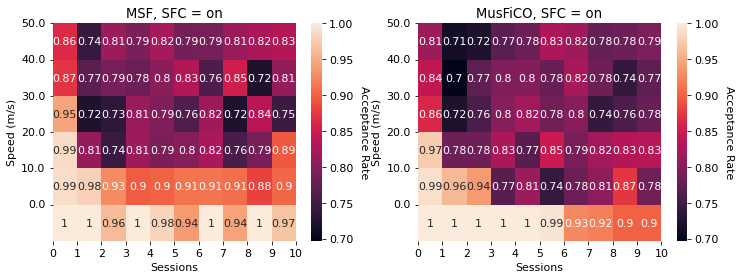

In [103]:
n_alg = len(np.unique(ar_mean_df.index.get_level_values("algorithm")))

fig, ax = plt.subplots(ncols=n_alg, figsize=(12, 4))
plt.rcParams["font.size"] = 11
vmin, vmax = 1000, 0
cmap = sns.color_palette("rocket", as_cmap=True)

for idx, (key, group) in enumerate(ar_mean_df.groupby(level=["sfc", "algorithm"])):
    vmin = group.min().min() if group.min().min() < vmin else vmin
    vmax = group.max().max() if group.max().max() > vmax else vmax
alg_names = ["MSF", "MusFiCO"]
for idx, (key, group) in enumerate(ar_mean_df.groupby(level=["sfc", "algorithm"])):
    group = group.iloc[::-1]
    velocity = group.index.get_level_values(-1).values
    sessions = group.columns.values
    sessions = list(range(0, len(sessions) + 1))
    yticks = np.arange(len(velocity))
    pk = sns.heatmap(group, ax=ax[idx], vmin=vmin, vmax=vmax, cmap=cmap, annot=True)
    cbar = pk.collections[0].colorbar
    cbar.set_label("Acceptance Rate", rotation=270, labelpad=15)

    ax[idx].set_yticks(ticks=yticks, labels=velocity)
    ax[idx].set_xticks(ticks=sessions, labels=sessions)
    ax[idx].set_ylabel("Speed (m/s)")
    ax[idx].set_xlabel("Sessions")
    ax[idx].set_title(f"{alg_names[idx]}, SFC = {key[0]}")

In [107]:
acceptance_series = grouped_df["success"].apply(resource_utilization)
bd_series = grouped_df["cache_utilization"].apply(resource_utilization)
cache_series = grouped_df["bandwidth_utilization"].apply(resource_utilization)
cpu_series = grouped_df["cpu_utilization"].apply(resource_utilization)

In [108]:
latency_df = df[df["latency"] != "None"]

latency_df["latency"] = latency_df["latency"].astype(float)

latency_series = latency_df.groupby(["sfc", "algorithm", "speed", "exec"])["latency"].apply(
    resource_utilization
)

/tmp/ipykernel_293751/3283871223.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latency_df['latency'] = latency_df['latency'].astype(float)


/tmp/ipykernel_293751/1064306563.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_293751/1064306563.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_293751/1064306563.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_293751/1064306563.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_293751/1064306563.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


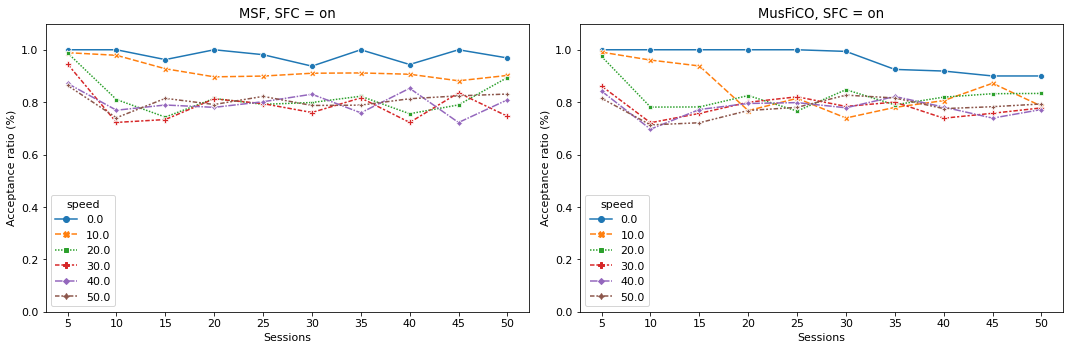

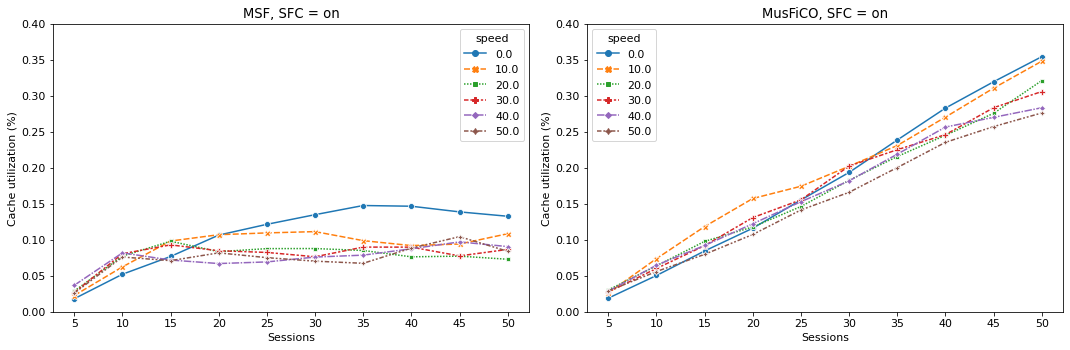

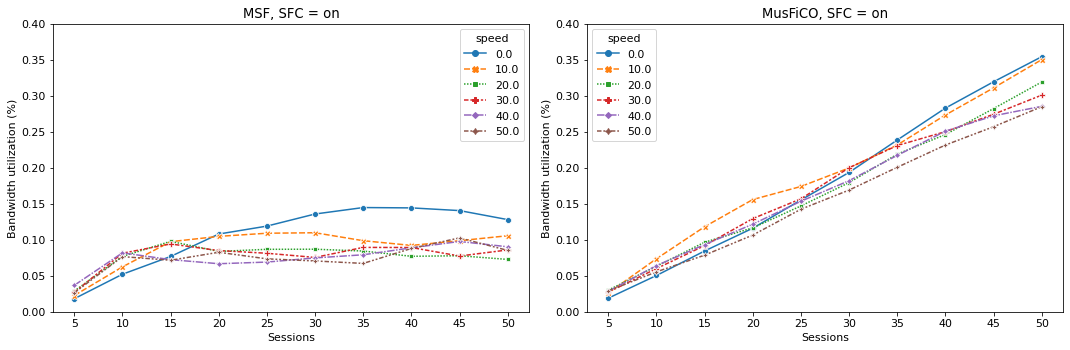

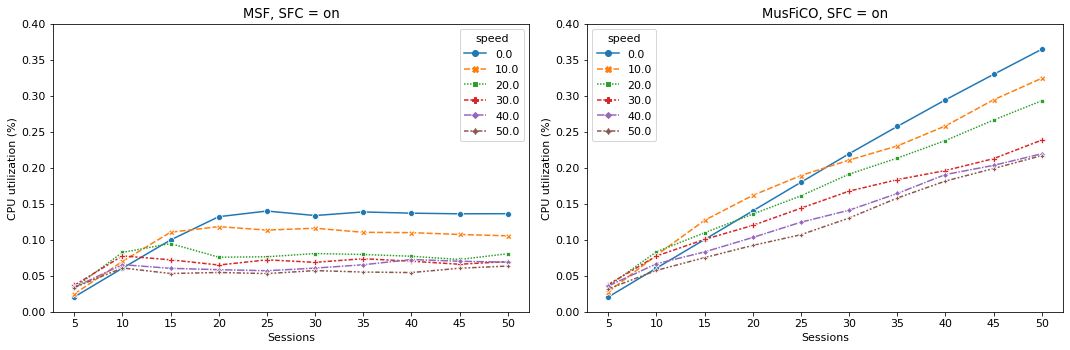

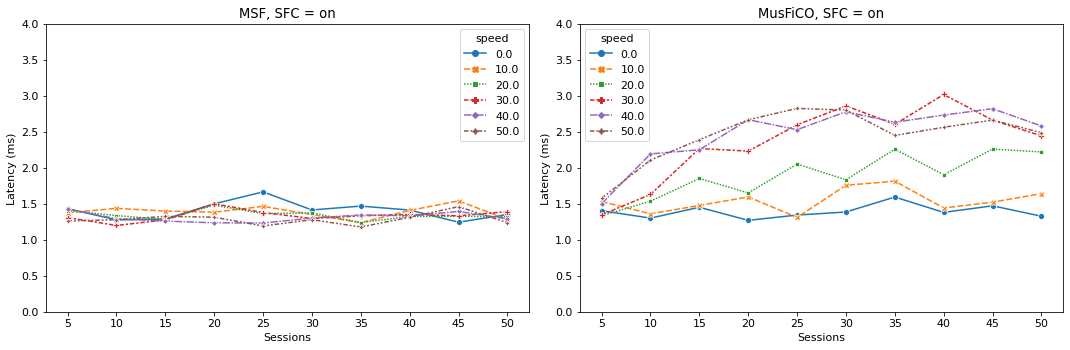

In [110]:
acceptance_array = plot_resource_utilization(
    acceptance_series, title="Acceptance ratio (%)", n_alg=n_alg, y_lim=(0, 1.1)
)
cache_array = plot_resource_utilization(
    cache_series, title="Cache utilization (%)", n_alg=n_alg, y_lim=(0, 0.4)
)
bandwidth_array = plot_resource_utilization(
    bd_series, title="Bandwidth utilization (%)", n_alg=n_alg, y_lim=(0, 0.4)
)
cpu_array = plot_resource_utilization(
    cpu_series, "CPU utilization (%)", n_alg=n_alg, y_lim=(0, 0.4)
)
latency_array = plot_resource_utilization(
    latency_series, title="Latency (ms)", n_alg=n_alg, y_lim=(0, 4)
)

In [39]:
def resource_utilization(ar_array) -> List:
    slices = np.array_split(ar_array, INTERVAL_LENGTH)
    resource_result = []
    for slice in slices:
        if len(slice) == 0:
            continue
        average_consumption = np.mean(slice)
        resource_result.append(average_consumption)

    return resource_result